=== Dataset Summary ===
Shape: (257673, 14)
Classes: 10
Attack Type
Normal Traffic    93000
Generic           58871
Exploits          44525
Fuzzers           24246
DoS               16353
Reconnaissance    13987
Analysis           2677
Backdoor           2329
Shellcode          1511
Worms               174
Name: count, dtype: int64


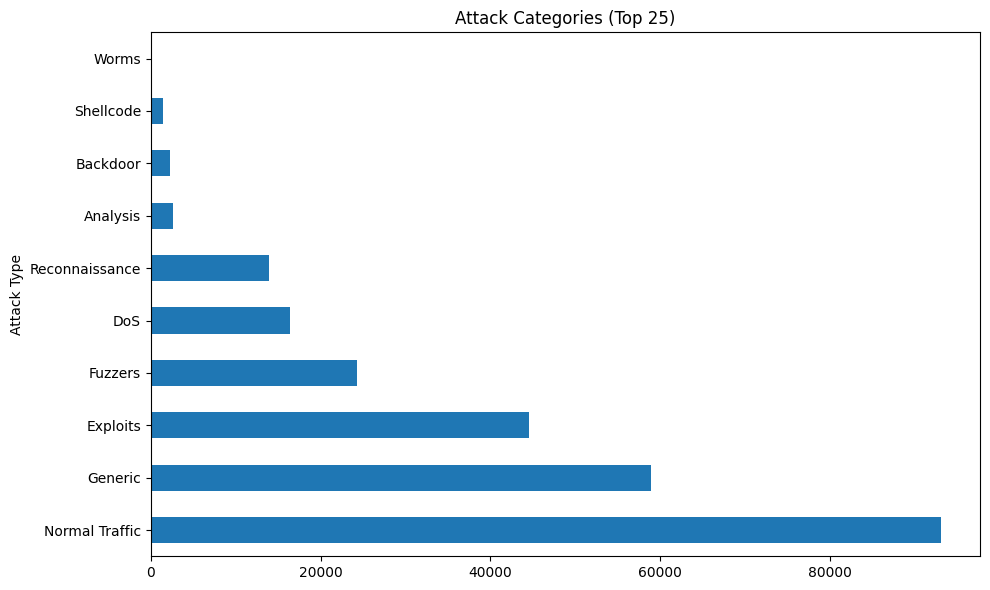

=== QAOA Feature Selection ===
Selected features: 14
['sbytes', 'sload', 'rate', 'smean', 'dur', 'dbytes', 'dinpkt', 'dload', 'dmean', 'dpkts', 'tcprtt', 'synack', 'ackdat', 'sinpkt']
Tasks created: 9

=== MAML Meta-Training ===
Meta step 1 completed
Meta step 2 completed
Meta step 3 completed
Meta step 4 completed
Meta step 5 completed
Meta step 6 completed
Meta step 7 completed
Meta step 8 completed
Meta step 9 completed
Meta step 10 completed
Meta step 11 completed
Meta step 12 completed
Meta step 13 completed
Meta step 14 completed
Meta step 15 completed

=== Final Training ===
Epoch 1 completed
Epoch 2 completed
Epoch 3 completed

=== Evaluation ===
Accuracy: 0.8954885029591539
Precision: 0.8794314519461202
Recall: 0.9693638985881281
F1 Score: 0.9222103469193218

Confusion Matrix:
 [[14223  4377]
 [ 1009 31926]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.76      0.84     18600
           1       0.88      0.97    

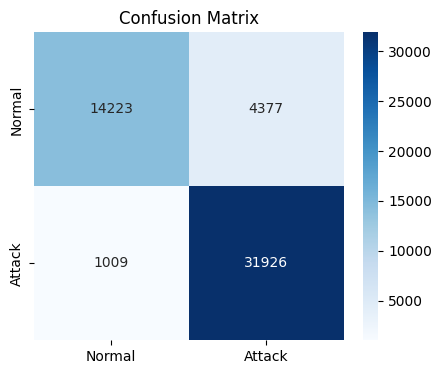

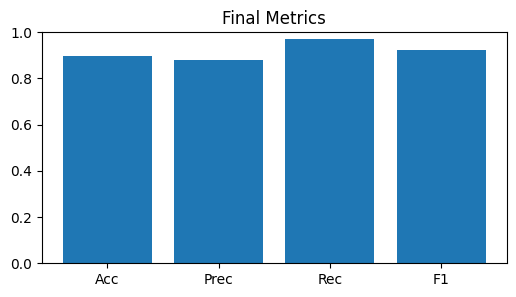

In [7]:
import os, random, math, numpy as np, pandas as pd, torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def set_seed(s=42):
    np.random.seed(s); random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)

set_seed(4)
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_unsw(train_path,test_path,m=200):
    df=pd.concat([pd.read_csv(train_path),pd.read_csv(test_path)],ignore_index=True)
    df=df.fillna(0).dropna(axis=1,how='all')
    df['attack_cat']=df['attack_cat'].astype(str)
    df['Attack Type']=np.where(df['label']==0,'Normal Traffic',df['attack_cat']).astype(str)
    df.loc[df['Attack Type'].isin(['','nan','NaN','None']),'Attack Type']='Normal Traffic'
    for c in ['proto','service','state']:
        if c in df.columns:
            f=df[c].astype(str).value_counts().to_dict()
            df[c+"_freq"]=df[c].astype(str).map(f).astype(float)
            df[c]=LabelEncoder().fit_transform(df[c].astype(str))
    num=df.select_dtypes(include=[np.number]).columns.tolist()
    for col in num:
        s=df[col]
        if s.std()>0:
            q1=s.quantile(0.25); q3=s.quantile(0.75); I=q3-q1
            df[col]=np.clip(s,q1-2*I,q3+2*I)
    X=df.drop(columns=[c for c in df.columns if c in ['Attack Type','attack_cat','label'] or any(x in c.lower() for x in ['id','index','time','timestamp'])])
    sc=RobustScaler()
    Xs=sc.fit_transform(X.values)
    y=df['Attack Type'].values
    yb=(y!='Normal Traffic').astype(int)
    sel=SelectKBest(mutual_info_classif,k='all')
    sel.fit(Xs,yb)
    scs=sel.scores_
    z=list(zip(X.columns.tolist(),scs))
    z.sort(key=lambda x:(0 if x[1] is None else x[1]),reverse=True)
    k=min(40,int(len(z)*0.40))
    feats=[f for f,_ in z[:k]]
    idx=[X.columns.get_loc(f) for f in feats]
    return Xs[:,idx],y,feats,df['Attack Type'].value_counts()

train_path=r"C:\Users\mchan\OneDrive\Pictures\Documents\4-1 Subjects\Mini Project\UNSW_NB15\UNSW_NB15\UNSW_NB15_training-set.csv"
test_path=r"C:\Users\mchan\OneDrive\Pictures\Documents\4-1 Subjects\Mini Project\UNSW_NB15\UNSW_NB15\UNSW_NB15_testing-set.csv"

X_all,y_attack,feature_names,counts=load_unsw(train_path,test_path)

print("=== Dataset Summary ===")
print("Shape:",X_all.shape)
print("Classes:",np.unique(y_attack).shape[0])
print(counts)

plt.figure(figsize=(10,6))
counts[:25].plot(kind="barh")
plt.title("Attack Categories (Top 25)")
plt.tight_layout()
plt.show()

class FastQAOA:
    def __init__(self,X,y): self.X=X; self.y=y; self.n=X.shape[1]
    def optimize(self,k=30):
        yb=(np.array(self.y)!='Normal Traffic').astype(int)
        sc=[]
        for j in range(self.n):
            c=self.X[:,j]
            try: cc=abs(np.corrcoef(c,yb)[0,1])
            except: cc=0
            sc.append(cc*np.var(c))
        idx=np.argsort(sc)[-k:]
        return np.sort(idx)

q=FastQAOA(X_all,y_attack)
sel_idx=q.optimize(30)
X_sel=X_all[:,sel_idx]
feature_names=[feature_names[i] for i in sel_idx]

print("=== QAOA Feature Selection ===")
print("Selected features:",len(feature_names))
print(feature_names[:20])

binary=(y_attack!='Normal Traffic').astype(int)

def build_tasks(X,y):
    labs=np.unique(y); t=[]
    for L in labs:
        if L=='Normal Traffic': continue
        p=np.where(y==L)[0]; n=np.where(y=='Normal Traffic')[0]
        if len(p)>=50 and len(n)>=50: t.append({'pos':p,'neg':n})
    return t

tasks=build_tasks(X_sel,y_attack)
print("Tasks created:",len(tasks))

def sample_task(t,X,y,s=8,q=15):
    rp=np.random.choice(t['pos'],s+q,replace=False)
    rn=np.random.choice(t['neg'],s+q,replace=False)
    ps,qs=rp[:s],rp[s:s+q]
    ns,qn=rn[:s],rn[s:s+q]
    sup=np.concatenate([ps,ns]); qry=np.concatenate([qs,qn])
    ys=(y[sup]!='Normal Traffic').astype(int)
    yq=(y[qry]!='Normal Traffic').astype(int)
    return sup,qry,X[sup],ys,X[qry],yq

class MHA(nn.Module):
    def __init__(self,d,h):
        super().__init__()
        self.h=h; self.dh=d//h
        self.qkv=nn.Linear(d,d*3); self.o=nn.Linear(d,d)
    def forward(self,x):
        B,T,C=x.size()
        qkv=self.qkv(x).reshape(B,T,3,self.h,self.dh).permute(2,0,3,1,4)
        q,k,v=qkv[0],qkv[1],qkv[2]
        a=torch.softmax((q@k.transpose(-2,-1))/math.sqrt(self.dh),dim=-1)
        return self.o((a@v).transpose(1,2).reshape(B,T,C))

class IDS(nn.Module):
    def __init__(self,i,h=12):
        super().__init__()
        self.l=nn.LSTM(i,h,batch_first=True,bidirectional=True)
        self.a=MHA(h*2,2); self.d=nn.Dropout(0.4); self.f=nn.Linear(h*2,2)
    def forward(self,x):
        if x.dim()==2: x=x.unsqueeze(1)
        h,_=self.l(x); a=self.a(h)
        return self.f(self.d(a[:,-1,:]))

def reptile(X,y,tasks,model_fn,iters=15,inner=2,lr=0.01,meta=0.1):
    m=model_fn().to(device)
    loss=nn.CrossEntropyLoss()
    print("\n=== MAML Meta-Training ===")
    for i in range(1,iters+1):
        t=np.random.choice(tasks)
        w=model_fn().to(device); w.load_state_dict(m.state_dict())
        opt=torch.optim.SGD(w.parameters(),lr=lr)
        si,qi,Xs,ys,Xq,yq=sample_task(t,X,y)
        ds=TensorDataset(torch.tensor(Xs,dtype=torch.float32),torch.tensor(ys,dtype=torch.long))
        dl=DataLoader(ds,batch_size=16,shuffle=True)
        for _ in range(inner):
            for xb,yb in dl:
                xb,yb=xb.to(device),yb.to(device)
                opt.zero_grad(); l=loss(w(xb),yb); l.backward(); opt.step()
        nw=m.state_dict(); ww=w.state_dict()
        for k in nw: nw[k]=nw[k]+meta*(ww[k]-nw[k])
        m.load_state_dict(nw)
        print("Meta step",i,"completed")
    return m

meta=reptile(X_sel,y_attack,tasks,lambda:IDS(X_sel.shape[1]))

bin_labels=(y_attack!='Normal Traffic').astype(int)
tr,ts=train_test_split(np.arange(len(bin_labels)),test_size=0.2,stratify=bin_labels,random_state=4)
Xtr,Xts=X_sel[tr],X_sel[ts]
ytr,yts=bin_labels[tr],bin_labels[ts]

print("\n=== Final Training ===")
model=IDS(X_sel.shape[1]).to(device)
model.load_state_dict(meta.state_dict())
opt=torch.optim.Adam(model.parameters(),lr=5e-4)
crit=nn.CrossEntropyLoss()

ds=TensorDataset(torch.tensor(Xtr,dtype=torch.float32),torch.tensor(ytr,dtype=torch.long))
dl=DataLoader(ds,batch_size=256,shuffle=True)

for ep in range(1,4):
    for xb,yb in dl:
        xb,yb=xb.to(device),yb.to(device)
        opt.zero_grad(); l=crit(model(xb),yb); l.backward(); opt.step()
    print("Epoch",ep,"completed")

print("\n=== Evaluation ===")
pred=[]
with torch.no_grad():
    for i in range(0,len(Xts),256):
        xb=torch.tensor(Xts[i:i+256],dtype=torch.float32).to(device)
        pred.append(torch.argmax(model(xb),1).cpu().numpy())
pred=np.concatenate(pred)

acc=accuracy_score(yts,pred)
prec=precision_score(yts,pred)
rec=recall_score(yts,pred)
f1=f1_score(yts,pred)
cm=confusion_matrix(yts,pred)

print("Accuracy:",acc)
print("Precision:",prec)
print("Recall:",rec)
print("F1 Score:",f1)
print("\nConfusion Matrix:\n",cm)
print("\nClassification Report:\n",classification_report(yts,pred,zero_division=0))

plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['Normal','Attack'],yticklabels=['Normal','Attack'])
plt.title("Confusion Matrix")
plt.show()

plt.figure(figsize=(6,3))
plt.bar(['Acc','Prec','Rec','F1'],[acc,prec,rec,f1])
plt.ylim(0,1)
plt.title("Final Metrics")
plt.show()
